# Step 1: Build and verify the isomip ice-shelf experiment

Before I change anything, I need to know that my build of MITgcm's `isomip` experiment gives the same answer as the official reference run, and I need to understand the setup. In this notebook I check the tools, describe the domain and the ice-shelf geometry, go through every setting in `data.shelfice`, compare my 20-step test run with the reference output, and time a longer run.

The builds and runs were made with `scripts/build.sh` and `scripts/run_experiment.sh`. They live in `~/mitgcm_runs/isomip/`, outside the repo. The experiment's `code/`, `input/` and `results/` folders were copied to `~/mitgcm_runs/isomip/source_copy/`, so the MITgcm clone itself is never changed.

I load the libraries and set all paths in one place.

In [1]:
%matplotlib inline

import os
import re
import math
import subprocess

import numpy as np
import matplotlib.pyplot as plt

HOME = os.path.expanduser("~")
MITGCM_ROOT = os.path.join(HOME, "models", "MITgcm")        # MITgcm clone (not modified)
COPY = os.path.join(HOME, "mitgcm_runs", "isomip", "source_copy")   # my copy of isomip code/, input/, results/
RUNS = os.path.join(HOME, "mitgcm_runs", "isomip")
REF_OUTPUT = os.path.join(COPY, "results", "output.txt")     # official reference output
TEST_RUNS = {"IEEE build": os.path.join(RUNS, "reference_test_ieee"),
             "fast (-O3) build": os.path.join(RUNS, "reference_test_fast")}
TIMING_RUNS = {"fast": os.path.join(RUNS, "timing_1month_fast"), "ieee": os.path.join(RUNS, "timing_1month_ieee")}

NX, NY, NR = 50, 100, 30        # grid size, from SIZE.h (sNx*nSx, sNy*nSy, Nr)
RHO_CONST = 1030.0              # rhoConst in the data file (kg/m^3)
GRAVITY = 9.81
COMPARE_FROM = 10               # compare monitor values from this monitor time on (see below)
DIGITS_IF_IDENTICAL = 16
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

I check the machine, the compiler and the MITgcm version. `git status` on the clone lists any changed tracked files: there should be none, because I only work on copies.

In [2]:
def run_command(command):
    return subprocess.run(command, shell=True, capture_output=True, text=True).stdout.strip()

print("processor:", run_command("uname -m"), "| build options file: darwin_arm64_gfortran (same as project 15)")
print("gfortran:", run_command("gfortran --version | head -1"))
print("MITgcm:", run_command(f"git -C {MITGCM_ROOT} describe --tags"), run_command(f"git -C {MITGCM_ROOT} log -1 --format=%h"))
changed = run_command(f"git -C {MITGCM_ROOT} status --short --untracked-files=no")
print("changed tracked files in the clone:", changed if changed else "none")
for build in ["build_reference_ieee", "build_reference_fast"]:
    flags = run_command(f"grep '^FOPTIM' {RUNS}/{build}/Makefile")
    print(f"{build}: executable exists: {os.path.exists(os.path.join(RUNS, build, 'mitgcmuv'))} | {flags}")
print("packages compiled:", run_command(f"grep -v '^#' {COPY}/code/packages.conf | tr '\\n' ' '"))

processor: arm64 | build options file: darwin_arm64_gfortran (same as project 15)
gfortran: GNU Fortran (Homebrew GCC 16.2.0) 16.2.0
MITgcm: checkpoint69q 853761d
changed tracked files in the clone: none
build_reference_ieee: executable exists: True | FOPTIM = -O0
build_reference_fast: executable exists: True | FOPTIM = -O3 -ftree-vectorize -funroll-loops
packages compiled: gfd ggl90 cd_code obcs shelfice steep_icecavity icefront diagnostics mnc


These are the settings that describe the setup, read from the experiment's `data` and `data.pkg` files exactly as provided.

In [3]:
keys = ["Tref", "Sref", "eosType", "rhoConst", "HeatCapacity_cp", "convertFW2Salt", "nIter0", "nTimeSteps", "deltaT",
        "monitorFreq", "usingSphericalPolarGrid", "ygOrigin", "delX", "delY", "delZ", "bathyFile",
        "diffKhT", "diffKzT", "viscAh", "viscAz", "bottomDragQuadratic"]
for line in open(os.path.join(COPY, "input", "data")):
    stripped = line.strip()
    for key in keys:
        if stripped.startswith(key):
            print(stripped)
print()
print(open(os.path.join(COPY, "input", "data.pkg")).read())

Tref = 30*-1.9,
Sref = 30*34.4,
viscAz=1.E-3,
viscAh=600.0,
diffKhT=100.0,
diffKzT=5.E-5,
bottomDragQuadratic=2.5E-3,
eosType='JMD95Z',
HeatCapacity_cp = 3974.0,
rhoConst=1030.,
rhoConst=1030.,
convertFW2Salt = 33.4,
nIter0=0,
nTimeSteps=20,
deltaT=1800.0,
monitorFreq=1.,
usingSphericalPolarGrid=.TRUE.,
ygOrigin = -80.0,
delX=50*0.3,
delY=100*0.1,
delZ=30*30.0,
bathyFile='bathy.box',

# Packages
 &PACKAGES
 useShelfIce=.TRUE.,
#useDiagnostics=.TRUE.,
#useMNC=.TRUE.,
 &



From those settings I work out the domain. The grid starts at 80°S (`ygOrigin`) and has 100 rows of 0.1° latitude and 50 columns of 0.3° longitude, so it covers 80°S to 70°S and 15° of longitude. There are 30 levels of 30 m, 900 m in total.

In [4]:
lat_edges = -80.0 + 0.1 * np.arange(NY + 1)
lon_edges = 0.0 + 0.3 * np.arange(NX + 1)
lat_c = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_c = 0.5 * (lon_edges[:-1] + lon_edges[1:])
dz = 30.0 * np.ones(NR)
earth_radius = 6.371e6
dy_km = earth_radius * np.deg2rad(0.1) / 1e3
dx_km_south = earth_radius * np.cos(np.deg2rad(lat_c[0])) * np.deg2rad(0.3) / 1e3
dx_km_north = earth_radius * np.cos(np.deg2rad(lat_c[-1])) * np.deg2rad(0.3) / 1e3
print(f"latitude {lat_edges[0]:.1f} to {lat_edges[-1]:.1f} degrees, longitude {lon_edges[0]:.1f} to {lon_edges[-1]:.1f} degrees")
print(f"grid cells: {dy_km:.1f} km north-south; {dx_km_south:.1f} km (south) to {dx_km_north:.1f} km (north) east-west")
print(f"domain about {dy_km * NY:.0f} km north-south and {dx_km_south * NX:.0f}-{dx_km_north * NX:.0f} km east-west, {dz.sum():.0f} m deep")

latitude -80.0 to -70.0 degrees, longitude 0.0 to 15.0 degrees
grid cells: 11.1 km north-south; 5.8 km (south) to 11.4 km (north) east-west
domain about 1112 km north-south and 291-569 km east-west, 900 m deep


The geometry is in two binary input files (64-bit, big-endian, 100 x 50): `bathy.box` is the seafloor depth and `icetopo.exp1` the depth of the ice base (the ice draft). Zero depth in `bathy.box` means land, a wall. Only the first column (west) and the first row (south) are land. MITgcm's grid wraps around by default (east connects to west, north to south), so these two walls also close the eastern and northern sides: the domain is a sealed box.

In [5]:
def read_input(name):
    return np.fromfile(os.path.join(COPY, "input", name), dtype=">f8").reshape(NY, NX)

bathy = read_input("bathy.box")
ice = read_input("icetopo.exp1")
print(f"seafloor: {bathy[bathy < 0].min():.0f} m everywhere in the ocean; walls (0 m): {np.sum(bathy == 0)} cells "
      f"(west column all land: {np.all(bathy[:, 0] == 0)}, south row all land: {np.all(bathy[0, :] == 0)})")
print(f"ice base: {ice.min():.2f} m at the southern edge to {ice.max():.2f} m; ice covers {np.sum(ice < 0)} of {NX * NY} cells")
for j in [1, 10, 20, 30, 40, 50, 99]:          # row 0 is the southern wall, so I start at row 1
    print(f"   latitude {lat_c[j]:.2f}: ice base {ice[j, 1]:8.2f} m, water column under the ice {ice[j, 1] - bathy[j, 1]:6.1f} m")

seafloor: -900 m everywhere in the ocean; walls (0 m): 149 cells (west column all land: True, south row all land: True)
ice base: -693.75 m at the southern edge to -200.00 m; ice covers 5000 of 5000 cells
   latitude -79.85: ice base  -681.25 m, water column under the ice  218.7 m
   latitude -78.95: ice base  -568.75 m, water column under the ice  331.2 m
   latitude -77.95: ice base  -443.75 m, water column under the ice  456.2 m
   latitude -76.95: ice base  -318.75 m, water column under the ice  581.2 m
   latitude -75.95: ice base  -200.00 m, water column under the ice  700.0 m
   latitude -74.95: ice base  -200.00 m, water column under the ice  700.0 m
   latitude -70.05: ice base  -200.00 m, water column under the ice  700.0 m


This cross-section shows the cavity along the domain (it is the same at every longitude). The ice base rises from about 694 m at the southern wall to 200 m at about 76°S, then stays flat. The water lies between the ice base and the 900 m seafloor.

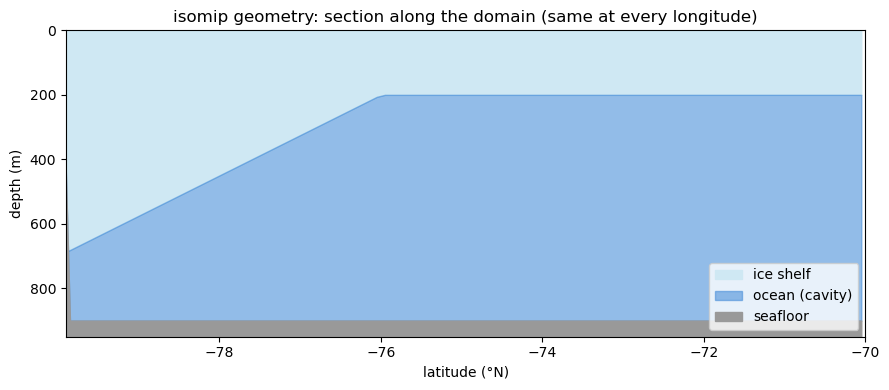

In [6]:
column = 10
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(lat_c, 0, -ice[:, column], color="#cfe8f3", label="ice shelf")
ax.fill_between(lat_c, -ice[:, column], -bathy[:, column], color="#4a90d9", alpha=0.6, label="ocean (cavity)")
ax.fill_between(lat_c, -bathy[:, column], 950, color="0.6", label="seafloor")
ax.set_xlim(lat_edges[1], lat_edges[-1])
ax.set_ylim(950, 0)
ax.set_xlabel("latitude (°N)")
ax.set_ylabel("depth (m)")
ax.set_title("isomip geometry: section along the domain (same at every longitude)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_geometry_section.png"), dpi=150)
plt.show()

Now `data.shelfice`, the settings of the ice-shelf package, next to the default value the package uses when a setting is not given (from `pkg/shelfice/shelfice_readparms.F`). I explain each one in TUTORIAL.md.

In [7]:
print(open(os.path.join(COPY, "input", "data.shelfice")).read())
defaults = {
    "SHELFICEheatTransCoeff (gamma_T, m/s)": "1.0e-4 (not set in the file, so this default is used)",
    "SHELFICEsaltTransCoeff (gamma_S, m/s)": "SHELFICEsaltToHeatRatio x gamma_T = 5.05e-3 x 1.0e-4 = 5.05e-7",
    "SHELFICElatentHeat (J/kg)": "334000",
    "rhoShelfIce (kg/m^3)": "917",
    "SHELFICEHeatCapacity_Cp of ice (J/kg/K)": "2000",
    "SHELFICEkappa, heat conduction into the ice (m^2/s)": "1.54e-6",
    "SHELFICEthetaSurface, ice surface temperature (degC)": "-20",
    "shiCdrag (only used with SHELFICEuseGammaFrict)": "0.0015",
    "useISOMIPTD (simple ISOMIP melt formula)": "default .FALSE., this experiment sets .TRUE.",
    "SHELFICEuseGammaFrict (velocity-dependent gamma)": "default .FALSE., this experiment sets .FALSE.",
}
for key, value in defaults.items():
    print(f"{key:55s} {value}")

# ===================================
# | Parameters for SHELFICE package |
# ===================================
 &SHELFICE_PARM01
 SHELFICEboundaryLayer = .TRUE.,
 SHELFICEtopoFile='icetopo.exp1',
 SHELFICEloadAnomalyFile = 'phi0surf.exp1.jmd95z',
 useISOMIPTD = .TRUE.,
 SHELFICEuseGammaFrict = .FALSE.,
 no_slip_shelfice = .false.,
 SHELFICEwriteState = .TRUE.,
 &

SHELFICEheatTransCoeff (gamma_T, m/s)                   1.0e-4 (not set in the file, so this default is used)
SHELFICEsaltTransCoeff (gamma_S, m/s)                   SHELFICEsaltToHeatRatio x gamma_T = 5.05e-3 x 1.0e-4 = 5.05e-7
SHELFICElatentHeat (J/kg)                               334000
rhoShelfIce (kg/m^3)                                    917
SHELFICEHeatCapacity_Cp of ice (J/kg/K)                 2000
SHELFICEkappa, heat conduction into the ice (m^2/s)     1.54e-6
SHELFICEthetaSurface, ice surface temperature (degC)    -20
shiCdrag (only used with SHELFICEuseGammaFrict)         0.0015
useISOMIPTD (simple ISOMIP mel

The key physics: the freezing point of seawater drops with pressure, by about 0.75 °C per 1000 dbar (roughly 1000 m). This figure shows the freezing point for salinity 34.4 g/kg against depth, with both formulas in the code: the simple ISOMIP one (non-linear in salinity, `useISOMIPTD`) and the linear one of the three-equation model. The vertical line is the model's initial temperature, -1.9 °C. Wherever the line is to the right of a curve, the water is above its local freezing point and can melt ice.

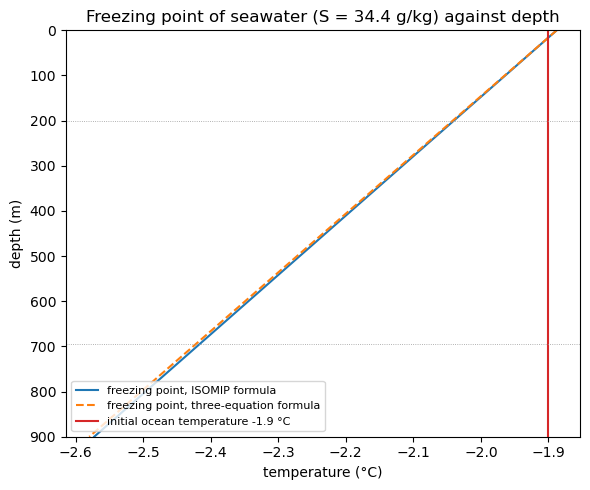

depth   0 m (  0.0 dbar): freezing point -1.888 °C (ISOMIP), -1.888 °C (three-equation); -1.9 °C water is -0.012 °C above it (ISOMIP)
depth 200 m (202.1 dbar): freezing point -2.040 °C (ISOMIP), -2.042 °C (three-equation); -1.9 °C water is +0.140 °C above it (ISOMIP)
depth 694 m (701.2 dbar): freezing point -2.416 °C (ISOMIP), -2.422 °C (three-equation); -1.9 °C water is +0.516 °C above it (ISOMIP)


In [8]:
def freezing_isomip(salt, p_dbar):
    return salt * (-0.0575 + 1.710523e-3 * np.sqrt(salt) - 2.154996e-4 * salt) - 7.53e-4 * p_dbar

def freezing_three_eq(salt, p_dbar):
    return -0.0575 * salt + 0.0901 - 7.61e-4 * p_dbar

depth = np.linspace(0, 900, 91)
p_dbar = RHO_CONST * GRAVITY * depth / 1e4        # hydrostatic pressure in dbar (1 dbar = 1e4 Pa)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(freezing_isomip(34.4, p_dbar), depth, label="freezing point, ISOMIP formula")
ax.plot(freezing_three_eq(34.4, p_dbar), depth, "--", label="freezing point, three-equation formula")
ax.axvline(-1.9, color="tab:red", label="initial ocean temperature -1.9 °C")
for d in [200, 694]:
    ax.axhline(d, color="0.6", lw=0.6, ls=":")
ax.set_ylim(900, 0)
ax.set_xlabel("temperature (°C)")
ax.set_ylabel("depth (m)")
ax.set_title("Freezing point of seawater (S = 34.4 g/kg) against depth")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_freezing_point_depth.png"), dpi=150)
plt.show()
for d in [0, 200, 694]:
    p = RHO_CONST * GRAVITY * d / 1e4
    print(f"depth {d:3d} m ({p:5.1f} dbar): freezing point {freezing_isomip(34.4, p):.3f} °C (ISOMIP), "
          f"{freezing_three_eq(34.4, p):.3f} °C (three-equation); -1.9 °C water is "
          f"{-1.9 - freezing_isomip(34.4, p):+.3f} °C above it (ISOMIP)")

Now the comparison with the reference. This function reads every `%MON` (monitor) line from an output file.

In [9]:
def read_monitor(path):
    values = {}
    for line in open(path):
        match = re.search(r"%MON (\S+)\s+=\s+(\S+)", line)
        if match is None:
            continue
        try:
            number = float(match.group(2).replace("D", "E"))
        except ValueError:
            continue
        values.setdefault(match.group(1), []).append(number)
    return values

ref = read_monitor(REF_OUTPUT)
ours = {label: read_monitor(os.path.join(path, "output.txt")) for label, path in TEST_RUNS.items()}
print("monitored quantities in the reference:", len(ref), "| monitor times:", len(ref["time_tsnumber"]))

monitored quantities in the reference: 135 | monitor times: 21


The model starts at rest with perfectly uniform temperature and salinity, so in the first steps many quantities are pure rounding noise. For example, the spread of salinity at step 0 is about 1e-13, from a field that should be perfectly uniform. Comparing the digits of noise means nothing, so I compare the second half of the test (monitor times 10 to 20), after the flow has started. I also leave out the mean sea-surface height, which the model keeps at zero: its values are rounding noise of about 1e-21.

In [10]:
print("examples of noise at step 0 (reference): theta_sd", ref["dynstat_theta_sd"][0], "| salt_sd", ref["dynstat_salt_sd"][0])
print("mean sea-surface height, steps 10, 15, 20 (reference):", [f"{v:.1e}" for v in ref["dynstat_eta_mean"][10::5]])
SKIP = ["dynstat_eta_mean"]

def matching_digits(a_list, b_list):
    worst = DIGITS_IF_IDENTICAL
    for a, b in zip(a_list, b_list):
        if a == b:
            continue
        worst = min(worst, -math.log10(abs(a - b) / max(abs(a), abs(b))))
    return worst

results = {}
for label in ours:
    digits = []
    for name in ref:
        if name in SKIP or len(ref[name]) <= COMPARE_FROM:
            continue        # skip noise-only quantities and quantities printed only at the start (grid statistics)
        digits.append((matching_digits(ours[label][name][COMPARE_FROM:], ref[name][COMPARE_FROM:]), name))
    digits.sort()
    results[label] = digits
    identical = sum(1 for d, n in digits if d == DIGITS_IF_IDENTICAL)
    print(f"{label}: {len(digits)} quantities, {identical} identical in every digit, worst {digits[0][0]:.1f} digits "
          f"({digits[0][1]}), median {np.median([d for d, n in digits]):.1f}")
print(f"flow at the end of the test (reference): largest u {ref['dynstat_uvel_max'][-1]:.2e} m/s, "
      f"lowest temperature {ref['dynstat_theta_min'][-1]:.4f} °C")

examples of noise at step 0 (reference): theta_sd 8.1268325402562e-14 | salt_sd 7.3185901783291e-13
mean sea-surface height, steps 10, 15, 20 (reference): ['-4.0e-21', '2.1e-21', '-1.3e-21']
IEEE build: 50 quantities, 13 identical in every digit, worst 9.6 digits (surfExpan_salt_mean), median 13.4
fast (-O3) build: 50 quantities, 10 identical in every digit, worst 7.5 digits (dynstat_eta_del2), median 10.8
flow at the end of the test (reference): largest u 1.79e-04 m/s, lowest temperature -1.9597 °C


This figure shows the matching digits for every compared quantity, sorted from worst to best, for both builds.

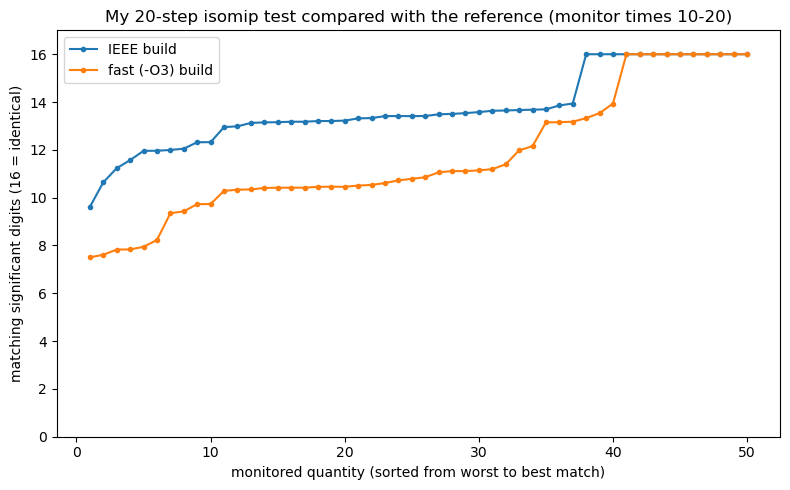

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [("IEEE build", "tab:blue"), ("fast (-O3) build", "tab:orange")]:
    d = [x for x, n in results[label]]
    ax.plot(range(1, len(d) + 1), d, "o-", ms=3, color=color, label=label)
ax.set_xlabel("monitored quantity (sorted from worst to best match)")
ax.set_ylabel("matching significant digits (16 = identical)")
ax.set_title("My 20-step isomip test compared with the reference (monitor times 10-20)")
ax.set_ylim(0, 17)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_reference_match.png"), dpi=150)
plt.show()

Finally, the timing. I ran one model month (1440 steps of 30 minutes) with the monitor printed only once. I use a 365-day year for planning, because this setup has no calendar.

In [12]:
def wall_seconds(run_dir):
    for line in open(os.path.join(run_dir, "time.txt")):
        if line.startswith("real"):
            return float(line.split()[1])

fast_month = wall_seconds(TIMING_RUNS["fast"])
ieee_month = wall_seconds(TIMING_RUNS["ieee"])
print(f"one model month (30 days): fast build {fast_month:.1f} s, IEEE build {ieee_month:.1f} s ({ieee_month / fast_month:.1f} times slower)")
per_year = fast_month * 365.0 / 30.0
print(f"fast build: about {per_year / 60:.1f} minutes per 365-day model year on one core")
for years in [1, 5, 10]:
    print(f"   {years:2d} model years: about {years * per_year / 3600:.1f} hours")

one model month (30 days): fast build 39.3 s, IEEE build 413.8 s (10.5 times slower)
fast build: about 8.0 minutes per 365-day model year on one core
    1 model years: about 0.1 hours
    5 model years: about 0.7 hours
   10 model years: about 1.3 hours
